# 📘 Tutorial 3: Momentum as a Dynamical System

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Tutorial 2**, we studied how the **geometry of the objective** shapes optimisation behaviour, focusing on curvature, conditioning, and scaling.

In this tutorial, we shift attention to the **optimisation algorithm itself**.

Instead of changing the problem, we now modify the **update rule**, and ask:

> Why does remembering the past help optimisation?

---

Gradient descent updates depend only on the current point:

$$
x_{t+1} = x_t - \eta \nabla f(x_t).
$$

Momentum introduces an additional variable — a **velocity** — that accumulates past gradients:

$$
v_{t+1} = \beta v_t + \nabla f(x_t), \quad
x_{t+1} = x_t - \eta v_{t+1}.
$$

This seemingly simple modification changes optimisation from a first-order process into a **system with memory and inertia**.

---

**This tutorial is designed to shift perspective**
- from *“momentum is a trick that speeds up training”*
- to *“momentum fundamentally changes the dynamics of optimisation.”*

---

**The emphasis is on developing intuition for**
- how momentum accumulates gradients over time,
- how velocity interacts with curvature in different directions,
- why momentum reduces zig-zagging in narrow valleys,
- how oscillations emerge from inertia,
- and when momentum improves or worsens convergence.

---

**Key ideas explored include**
- momentum as a second-order dynamical system,
- the role of the momentum parameter $\beta$ as temporal smoothing,
- acceleration vs oscillation trade-offs,
- how momentum reshapes stability regions,
- and when momentum becomes harmful in well-conditioned problems.

---

This tutorial builds directly on the geometric insights from Tutorial 2 and shows how **algorithmic changes interact with problem geometry**, explaining why momentum is often essential in difficult optimisation settings.

These ideas will form the foundation for understanding more advanced methods, including:
- Nesterov acceleration,
- adaptive optimisers (Adam, RMSProp),
- and large-scale stochastic optimisation.

---

**Recommended prerequisites**
- Completion of **Tutorial 2** in Part 2
- Familiarity with gradient descent dynamics
- Basic understanding of conditioning and curvature

---

**Author**: Angze Li

**Last updated**: 2026-04-14

**Version**: v2.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

set_seed(0)

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

def contour_plot(A, xlim=(-3,3), ylim=(-3,3), levels=30):
    A = torch.tensor(A)

    x1 = np.linspace(*xlim, 200)
    x2 = np.linspace(*ylim, 200)
    X1, X2 = np.meshgrid(x1, x2)

    Z = np.zeros_like(X1)

    for i in range(X1.shape[0]):
        pts = torch.tensor(np.stack([X1[i], X2[i]], axis=-1))
        Z[i] = (0.5 * (pts * (pts @ A.T)).sum(dim=1)).numpy()

    return X1, X2, Z

In [2]:
def gd_step(x, grad, lr):
    return x - lr * grad

@torch.no_grad()
def run_gd(x0, loss_grad_fn, lr, steps=60):
    x = x0.clone()
    xs, losses, grad_norms = [x.clone()], [], []

    for _ in range(steps):
        L, g = loss_grad_fn(x)
        losses.append(float(L))
        grad_norms.append(float(g.norm()))
        x = gd_step(x, g, lr)
        xs.append(x.clone())

    return torch.stack(xs), np.array(losses), np.array(grad_norms)

def quad2d(A):
    A = torch.tensor(A)

    def fn(x):
        L = 0.5 * x @ (A @ x)
        g = A @ x
        return L, g

    return fn

## 1. Introducing Momentum: Accumulation and Inertia

So far, we have studied **vanilla gradient descent**, where each update depends only on the **current gradient**:

$$x_{t+1} = x_t - \eta \nabla f(x_t).$$

In this tutorial we now modify the dynamics by allowing the optimiser to **remember part of its past motion**.

This idea is called **momentum**.

---

### What does each term mean?

1. **The gradient term**: $\nabla f(x_t)$
This is the same local slope information used in ordinary gradient descent.


It tells us which direction the loss is increasing most steeply, so $-\nabla f(x_t)$ is the **local downhill direction**.

2. **The velocity term**: $v_t$
Unlike vanilla gradient descent, momentum keeps track of a **running accumulation of past gradients**.

The update

$$v_{t+1} = \beta v_t + \nabla f(x_t)$$

means:
- if the gradients point in a **consistent direction over time**, they reinforce each other,
- if the gradients alternate in sign, the accumulated velocity partially cancels them.

This is why momentum can:
- accelerate motion in shallow directions,
- while smoothing out oscillations in steep directions.

3. **The momentum parameter**: $\beta$
The coefficient $\beta$ controls **how much memory the system retains**.
- **small** $\beta$ → little memory, behaviour closer to gradient descent
- **large** $\beta$ → strong inertia, more persistent motion
- **too large** $\beta$ → overshooting and oscillation can become severe

So $\beta$ controls the trade-off between:
- **smoothing / acceleration**
- and **instability / ringing**

---

### What the code does？

#### Initialisation
```python
x = x0.clone()
v = torch.zeros_like(x)
```
We begin from an initial point `x0`, and initialise the velocity `v` to zero.

This means the optimiser starts from rest.

#### Tracking the trajectory
```python
xs, vs, losses, grad_norms = [x.clone()], [v.clone()], [], []
```
We record four objects throughout the optimisation:
- `xs` – the parameter trajectory $x_t$
- `vs` – the velocity trajectory $v_t$
- `losses` – the loss value at each step
- `grad_norms` – the norm of the gradient at each step

These let us inspect:
- where the optimiser moves
- how strongly it is moving
- how fast the loss decreases
- and how the gradient evolves over time

#### Main loop
At each step:
```python
L, g = loss_grad_fn(x)
```
we compute:
- the current loss `L`
- the current gradient `g`

Then:
```python
v = beta * v + g
x = x - lr * v
```

we:
	1.	update the velocity by combining **past motion** and **current gradient**
	2.	update the parameters using that velocity

This is the essential difference from vanilla gradient descent.

#### Why use `@torch.no_grad()` here?
The decorator
```python
@torch.no_grad()
```
tells PyTorch **not to build a computation graph** during these optimisation steps.

That is appropriate here because:
- we are not differentiating through the optimiser itself,
- we only want to simulate the dynamics,
- and we want the code to remain simple and efficient.

---

### Physical interpretation: the “heavy ball”

The name **heavy-ball momentum** comes from a simple physical analogy.

Imagine a ball rolling on a hilly surface:
- the **gradient** corresponds to the local slope of the hill,
- the **velocity** corresponds to the ball’s current motion,
- the parameter $\beta$ controls how much of that motion persists.

In this picture:
- vanilla gradient descent is like a ball that forgets its velocity at every step,
- momentum is like a ball with inertia, which keeps moving once it has started.

This helps explain why momentum can be useful:
- in **flat directions**, inertia helps the optimiser keep moving rather than creeping slowly,
- in **steep directions**, repeated sign changes in the gradient can be averaged out,
- but if inertia is too strong, the ball can **overshoot** and bounce back and forth.

So momentum is not magic — it is simply **memory plus inertia**.

In [3]:
@torch.no_grad()
def run_momentum(x0, loss_grad_fn, lr, beta=0.9, steps=60):
    x = x0.clone()
    v = torch.zeros_like(x)

    xs, vs, losses, grad_norms = [x.clone()], [v.clone()], [], []

    for _ in range(steps):
        L, g = loss_grad_fn(x)
        losses.append(float(L))
        grad_norms.append(float(g.norm()))

        v = beta * v + g
        x = x - lr * v

        xs.append(x.clone())
        vs.append(v.clone())

    return (
        torch.stack(xs),
        torch.stack(vs),
        np.array(losses),
        np.array(grad_norms),
    )

## 2. Comparing Gradient Descent and Momentum

We now compare **vanilla gradient descent** and **momentum-based optimisation** on the same quadratic objective.

The goal is to understand how **adding memory (momentum)** changes the optimisation trajectory — not just the final loss.

---

### Experimental setup

We consider the quadratic objective defined by

$$A =
\begin{pmatrix}
10 & 0 \\
0 & 1
\end{pmatrix},$$

which produces an **ill-conditioned loss landscape**:
- steep curvature along $x_1$,
- shallow curvature along $x_2$.

This creates a **narrow valley**, where optimisation is known to be difficult.

Both methods are initialised at the same point:

$$x_0 = (2,2).$$

---

### Two optimisation methods

We run:
- **Gradient descent**
    - learning rate: $\eta = 0.15$
- **Momentum**
    - learning rate: \eta = 0.02
    - momentum: \beta = 0.8

Note that the learning rates are **not the same** — momentum typically requires a **smaller** step size for stability.

---

### What is being plotted

For each method, we plot:
- **contour lines** of the quadratic objective (level sets of the loss),
- the **trajectory** of the optimisation iterates $x_t$.

This lets us directly compare:
- how each method moves through the landscape,
- how efficiently it approaches the minimum.

---

### What to look for

1. **Shape of the trajectory**
- Gradient descent tends to **zig-zag** across the narrow valley.
- Momentum produces **smoother, more directed motion**, due to accumulated velocity.

2. **Movement along different directions**
- In the steep direction:
    - gradient descent quickly corrects but oscillates,
    - momentum may overshoot slightly due to inertia.
- In the flat direction:
    - gradient descent moves slowly,
    - momentum can **accelerate progress** by building up velocity.

3. Overall behaviour
- Momentum introduces **inertia**, so the path is less reactive to local gradients.
- This can make the trajectory look more “fluid,” but also potentially less stable if not tuned properly.

---

### Key takeaway

> **Momentum changes not just how fast optimisation happens, but how it moves through the landscape.**

It transforms the dynamics from:
- a sequence of local corrections (gradient descent),
into:
- a system with **memory and inertia**, capable of accelerating through flat regions and smoothing oscillations.

However, this also introduces:
- sensitivity to hyperparameters,
- and the possibility of overshooting.

---

In the next sections, we will quantify these effects and study how **momentum parameters control this trade-off**.

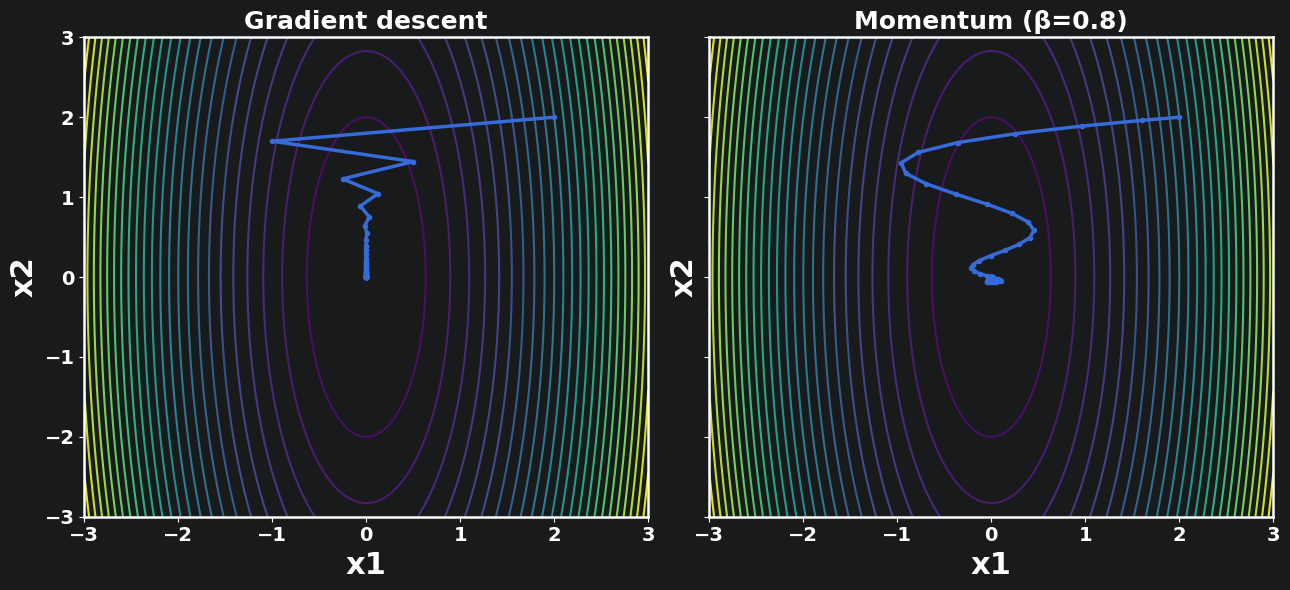

In [4]:
A = np.array([
    [10.0, 0.0],
    [0.0,  1.0]
])

f = quad2d(A)
x0 = torch.tensor([2.0, 2.0])

lr_gd = 0.15
lr_m = 0.02
beta = 0.8
steps = 100

xs_gd, losses_gd, _ = run_gd(x0, f, lr=lr_gd, steps=steps)
xs_m, vs_m, losses_m, _ = run_momentum(x0, f, lr=lr_m, beta=beta, steps=steps)

X1, X2, Z = contour_plot(A)

fig, axes = plt.subplots(1, 2, figsize=(13,6), sharex=True, sharey=True)

# GD
axes[0].contour(X1, X2, Z, levels=30)
path = xs_gd.numpy()
axes[0].plot(path[:,0], path[:,1], "-o", markersize=3, linewidth=2.5)
axes[0].set_title("Gradient descent", fontsize=18, fontweight="bold")
axes[0].set_xlabel("x1", fontsize=22, fontweight="bold")
axes[0].set_ylabel("x2", fontsize=22, fontweight="bold")
style_ax(axes[0])

# Momentum
axes[1].contour(X1, X2, Z, levels=30)
path = xs_m.numpy()
axes[1].plot(path[:,0], path[:,1], "-o", markersize=3, linewidth=2.5)
axes[1].set_title(f"Momentum (β={beta:.1f})", fontsize=18, fontweight="bold")
axes[1].set_xlabel("x1", fontsize=22, fontweight="bold")
axes[1].set_ylabel("x2", fontsize=22, fontweight="bold")
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 3. Loss vs Steps: Quantitative Comparison

While contour plots show **how the optimisation moves**, we now examine **how fast it converges**.

This cell compares gradient descent and momentum by plotting the **loss value over iterations**.

---

### What is being plotted

- The $x$-axis shows the iteration number $t$
- The $y$-axis shows the loss $L(x_t)$, on a **logarithmic scale**

We plot two curves:
- **Gradient descent** with learning rate $\eta = {lr_gd}$
- **Momentum** with learning rate $\eta = {lr_m}$ and $\beta = {beta}$

The log scale is important because:
- it makes exponential convergence appear as a **straight line**
- and highlights differences in **convergence rate**

---

### How to interpret the curves

1. **Slope of the curve**
- A steeper downward slope indicates **faster convergence**
- Straight lines suggest **stable exponential decay**

2. Oscillations
- Smooth curves indicate stable updates
- Oscillatory or jagged curves indicate **overshooting or inertia effects**

3. Final loss level
- Lower curves correspond to **better optimisation performance**
- Differences become more visible at later iterations

---

### What this comparison reveals

This plot complements the geometric view:
- Gradient descent often shows **smooth and predictable decay**
- Momentum may:
    - accelerate convergence in some regimes,
    - or introduce oscillations if parameters are not well tuned

Importantly, momentum does not guarantee faster convergence — its effect depends on:
- the **conditioning of the problem**,
- and the choice of **learning rate and momentum parameter**

---

### Key takeaway

> **The benefit of momentum must be evaluated quantitatively, not just visually.**

Even if a trajectory looks smoother or more “direct,” the loss curve reveals whether it is actually **converging faster**.

In the next sections, we will explore how tuning $\beta$ changes this behaviour and identify the regime where momentum is most effective.

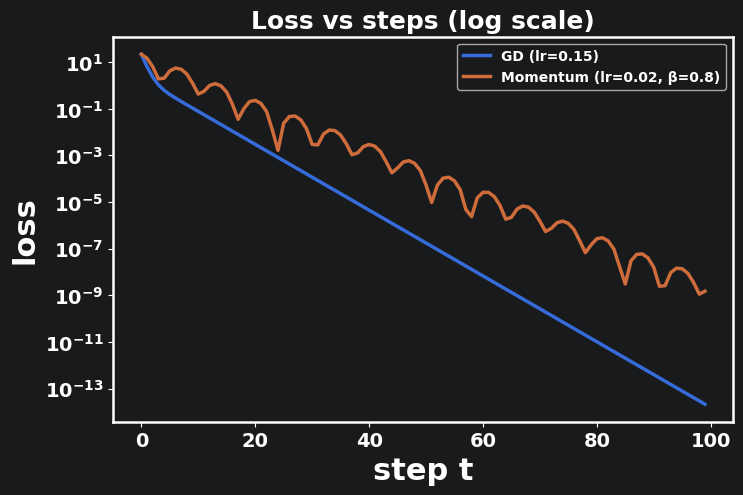

In [5]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(losses_gd, linewidth=2.5, label=f"GD (lr={lr_gd})")
ax.plot(losses_m, linewidth=2.5, label=f"Momentum (lr={lr_m}, β={beta})")

ax.set_yscale("log")
ax.set_title("Loss vs steps (log scale)", fontsize=18, fontweight="bold")
ax.set_xlabel("step t", fontsize=22, fontweight="bold")
ax.set_ylabel("loss", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"})

style_ax(ax)
plt.show()

## 4. Decomposing the Dynamics: Steep vs Flat Directions

To better understand how momentum changes optimisation behaviour, we now look at each coordinate separately.

Recall that for the quadratic objective

$$A = 
\begin{pmatrix} 
10 & 0 
\\ 
0 & 1 
\end{pmatrix},$$

the two directions behave very differently:
- $x_1$: **steep direction** (large curvature)
- $x_2$: **flat direction** (small curvature)

---

### What is being plotted

We plot the evolution of each coordinate over iterations:
- **Left panel**: $x_1^{(t)}$ — the steep direction
- **Right panel**: $x_2^{(t)}$ — the flat direction

For each, we compare:
- **Gradient descent**
- **Momentum**

---

### How to interpret the plots

1. **Steep direction** ($x_1$)
- Gradient descent:
    - quickly corrects toward zero
    - may exhibit small oscillations due to large curvature
- Momentum:
    - introduces **inertia**
    - tends to **overshoot more strongly**
    - may oscillate more noticeably

👉 This is where momentum can **hurt stability** if too strong.


2. Flat direction ($x_2$)
- Gradient descent:
    - moves slowly due to weak gradients
    - progress is gradual and limited
- Momentum:
    - accumulates consistent gradients over time
    - builds up **velocity**
    - can move **significantly faster**

👉 This is where momentum provides its main benefit.

---

### Key insight

> **Momentum behaves differently across directions with different curvature.**

- It tends to **amplify motion** in flat directions (good)
- But can **exaggerate oscillations** in steep directions (risky)

This directional imbalance explains:
- why momentum can accelerate optimisation,
- and why it can also introduce instability.

---

### Why this matters

This decomposition reveals the core mechanism behind momentum:

> It is not uniformly “better” — it selectively modifies dynamics depending on the geometry of the problem.

Understanding this is crucial before:
- tuning $\beta$,
- choosing learning rates,
- or applying momentum in more complex models.

In the next section, we will explore how varying $\beta$ controls this trade-off.

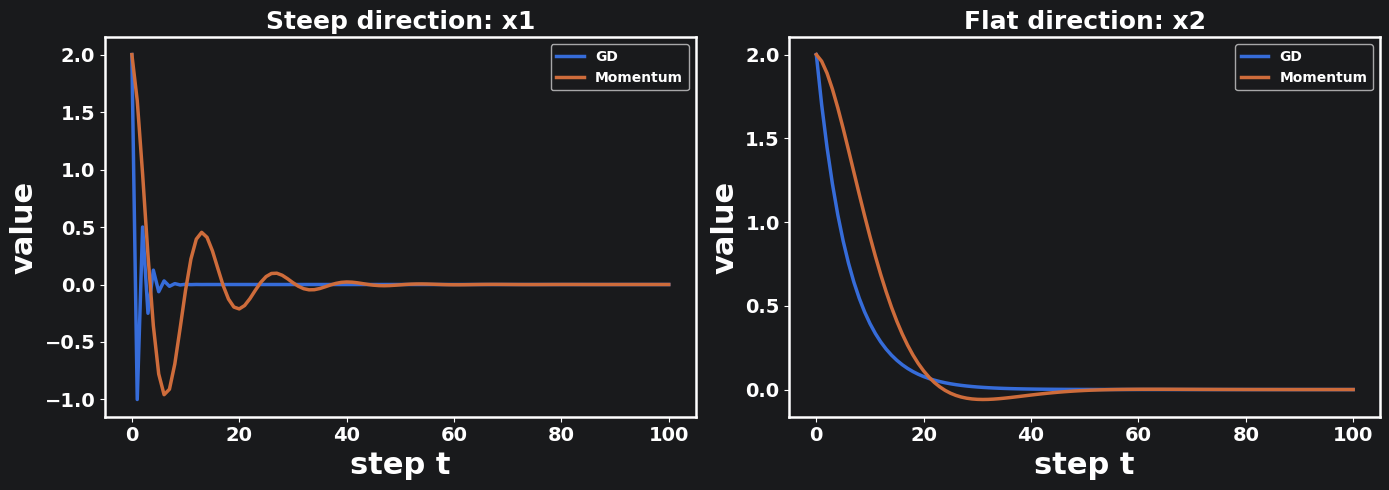

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

axes[0].plot(xs_gd[:,0].numpy(), linewidth=2.5, label="GD")
axes[0].plot(xs_m[:,0].numpy(), linewidth=2.5, label="Momentum")
axes[0].set_title("Steep direction: x1", fontsize=18, fontweight="bold")
axes[0].set_xlabel("step t", fontsize=22, fontweight="bold")
axes[0].set_ylabel("value", fontsize=22, fontweight="bold")
axes[0].legend(prop={"size":10, "weight":"bold"})
style_ax(axes[0])

axes[1].plot(xs_gd[:,1].numpy(), linewidth=2.5, label="GD")
axes[1].plot(xs_m[:,1].numpy(), linewidth=2.5, label="Momentum")
axes[1].set_title("Flat direction: x2", fontsize=18, fontweight="bold")
axes[1].set_xlabel("step t", fontsize=22, fontweight="bold")
axes[1].set_ylabel("value", fontsize=22, fontweight="bold")
axes[1].legend(prop={"size":10, "weight":"bold"})
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 5. Sweeping the Momentum Parameter $\beta$

We now investigate how the **momentum parameter** $\beta$ affects optimisation behaviour.

Recall that $\beta$ controls how much of the past velocity is retained:

$$v_{t+1} = \beta v_t + \nabla f(x_t).$$

This makes $\beta$ a key parameter **governing memory and inertia** in the system.

---

### What is being plotted
- The **loss** $L(x_t)$ is plotted over iterations
- The y-axis is on a **log scale** to highlight convergence rates
- Each curve corresponds to a different value of $\beta$

All other settings are fixed:
- same objective function
- same initial point
- same learning rate

This isolates the effect of **changing only** $\beta$.

---

### How to interpret the curves

1. $\beta = 0$ **(no momentum)**
- This reduces to **vanilla gradient descent**
- Smooth but relatively slow convergence

2. **Moderate** $\beta$ (e.g. 0.3–0.6)
- Faster decrease in loss
- Momentum begins to **accelerate progress**
- Small oscillations may appear

👉 This is often the **most effective regime**

3. **Large** $\beta$
- Strong inertia leads to **persistent oscillations**
- Loss decreases more slowly or irregularly
- Convergence can degrade or become unstable

---

### The key trade-off

> **Momentum introduces a trade-off between smoothing and stability.**

Increasing $\beta$:
- ✔ accelerates movement in consistent directions
- ✘ amplifies oscillations and overshooting

There is typically an **optimal intermediate value** of $\beta$ that balances these effects.

---

### Key takeaway

> **Momentum is not “more is better” — it must be tuned.**

This experiment shows that:
- too little momentum → insufficient acceleration
- too much momentum → excessive oscillation
- just the right amount → fastest convergence

In practice, $\beta$ and the learning rate must be chosen **together**, as they jointly determine the dynamics of optimisation.

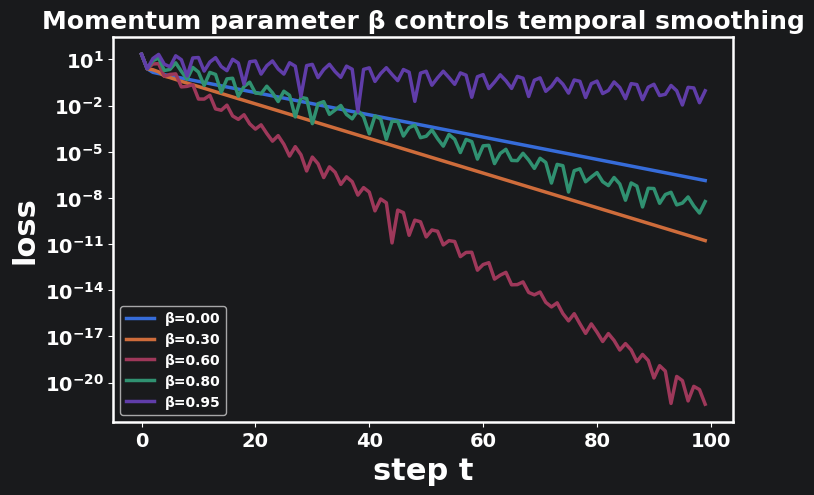

In [7]:
A = np.array([
    [10.0, 0.0],
    [0.0,  1.0]
])

f = quad2d(A)
x0 = torch.tensor([2.0, 2.0])
lr = 0.08
steps = 100
betas = [0.0, 0.3, 0.6, 0.8, 0.95]

fig, ax = plt.subplots(figsize=(8,5))

for beta in betas:
    xs, vs, losses, _ = run_momentum(x0, f, lr=lr, beta=beta, steps=steps)
    ax.plot(losses, linewidth=2.5, label=f"β={beta:.2f}")

ax.set_yscale("log")
ax.set_title("Momentum parameter β controls temporal smoothing", fontsize=18, fontweight="bold")
ax.set_xlabel("step t", fontsize=22, fontweight="bold")
ax.set_ylabel("loss", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"})
style_ax(ax)
plt.show()

## 6. Stability and Learning Rate: Gradient Descent vs Momentum

So far, we have seen that momentum *can* **accelerate optimisation**.

But an equally important question is:

> **How does momentum affect stability?**

This experiment explores how the **choice of learning rate** influences whether optimisation remains stable or diverges.

---

### What the code does

1. **Define a stability check**
We classify a run as **stable (1)** or **unstable (0)** based on two conditions:
- If the loss becomes non-finite (NaN or inf) → unstable
- If the parameters grow beyond a large threshold → unstable

Otherwise, the run is considered stable.

2. **Sweep over learning rates**
We test a range of learning rates:

$$\eta \in [0.001, 0.30]$$

For each value, we run:
- Gradient descent
- Momentum (with $\beta = 0.8$)

and record whether each method remains stable.


3. **Plot the results**
The plot shows:
- $x$-axis: learning rate
- $y$-axis: stability (1 = stable, 0 = unstable)

Each curve indicates the range of learning rates for which the method works.

---

### How to interpret the figure

**Gradient Descent (blue)**
- Stable up to a certain learning rate
- Beyond that threshold, it diverges sharply

This reflects the classical result:

> gradient descent becomes unstable when the step size is too large relative to curvature.

**Momentum (orange, $\beta = 0.8$)**
- Remains stable over a **wider range of learning rates**
- Does not exhibit the same sharp breakdown in this range

This suggests:

> **momentum can expand the stable learning rate region**

---

### What this means

Momentum is not just about speed — it also changes the **stability properties** of optimisation.
- Gradient descent:
    - stability is tightly constrained by curvature
- Momentum:
    - introduces inertia, which can **stabilise** updates across steps

However, this does not mean momentum is always safer:
- for different $\beta$ or higher learning rates, instability can still occur (often more dramatically)

---

### Key takeaway

> **Momentum reshapes the stability landscape of optimisation.**

It can:
- allow higher learning rates in some regimes,
- smooth out unstable behaviour,
- but also introduce *new* failure modes if mis-tuned.

Understanding this trade-off is crucial before applying momentum in real problems.

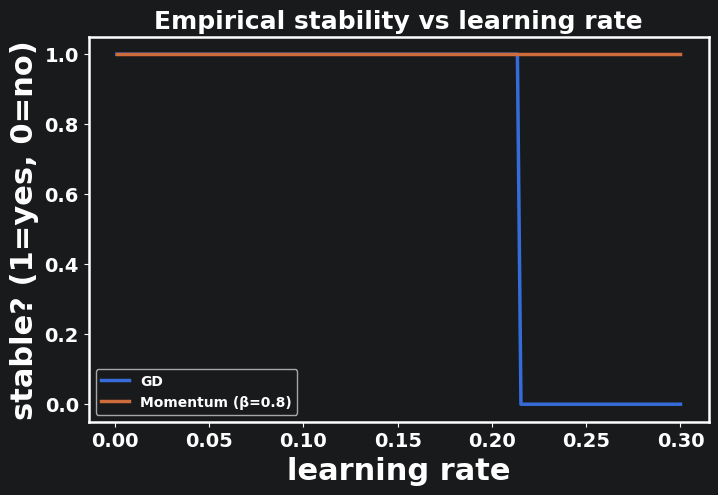

In [8]:
def classify_momentum(A, x0, lr, beta=0.9, steps=100, explode_thresh=1e6):
    f = quad2d(A)
    xs, vs, losses, _ = run_momentum(x0, f, lr=lr, beta=beta, steps=steps)

    if np.any(~np.isfinite(losses)):
        return 0
    if np.max(np.abs(xs.numpy())) > explode_thresh:
        return 0
    return 1

A = np.array([
    [10.0, 0.0],
    [0.0,  1.0]
])

x0 = torch.tensor([2.0, 2.0])
lrs = np.linspace(0.001, 0.30, 160)

stable_gd = []
stable_m  = []

for lr in lrs:
    xs, losses, _ = run_gd(x0, quad2d(A), lr=lr, steps=100)
    gd_ok = 1
    if np.any(~np.isfinite(losses)) or np.max(np.abs(xs.numpy())) > 1e6:
        gd_ok = 0
    stable_gd.append(gd_ok)

    stable_m.append(classify_momentum(A, x0, lr, beta=0.8, steps=100))

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(lrs, stable_gd, linewidth=2.5, label="GD")
ax.plot(lrs, stable_m, linewidth=2.5, label="Momentum (β=0.8)")
ax.set_title("Empirical stability vs learning rate", fontsize=18, fontweight="bold")
ax.set_xlabel("learning rate", fontsize=22, fontweight="bold")
ax.set_ylabel("stable? (1=yes, 0=no)", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"})
style_ax(ax)
plt.show()

## 7. When Momentum Hurts: Well-Conditioned Problems

So far, we have seen that momentum can significantly improve optimisation — especially in **ill-conditioned problems with narrow valleys**.

But what happens when the problem is already **well-conditioned**?

---

### Experimental setup

We now consider the quadratic objective:

$$A =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix},$$

which is **perfectly isotropic**:
- curvature is the same in all directions,
- level sets are circular,
- there is no imbalance between directions.

This represents the *best-case scenario* for optimisation.

We compare:
- **Gradient descent** with learning rate $\eta = 0.3$
- **Momentum** with the same learning rate and $\beta = 0.9$

---

### What is being plotted
- The **loss** $L(x_t)$ over iterations
- On a log scale to reveal convergence behaviour

---

### What we observe

**Gradient descent (blue)**
- Smooth, monotonic decrease
- Straight line on log scale → **stable exponential convergence**
- Efficient and predictable

**Momentum (orange)**
- **Strong oscillations** in the loss
- **Repeated overshooting** of the minimum
- Much slower reduction in loss overall

---

### Why momentum hurts here

In this problem:
- all directions have the same curvature,
- gradients are already well-aligned,
- there is **no zig-zag** behaviour to fix.

So momentum adds:
- **inertia without necessity**
- leading to **overshooting** and **oscillation**

Instead of helping, it:

> disrupts an already optimal optimisation path.

---

### Key insight

> **Momentum is most useful when geometry is difficult — and can be harmful when it is not.**

- In ill-conditioned problems:
    - momentum reduces zig-zag and accelerates progress
- In well-conditioned problems:
    - gradient descent is already efficient
    - momentum introduces unnecessary instability

---

### Takeaway

Momentum is not universally beneficial.

Its usefulness depends on the **geometry of the objective**:
- ✔ helpful when curvature is highly anisotropic
- ✘ harmful when the problem is already well-conditioned

This reinforces a central theme of the tutorial:

> **Optimisation behaviour is governed by geometry — and algorithms must match that geometry.**

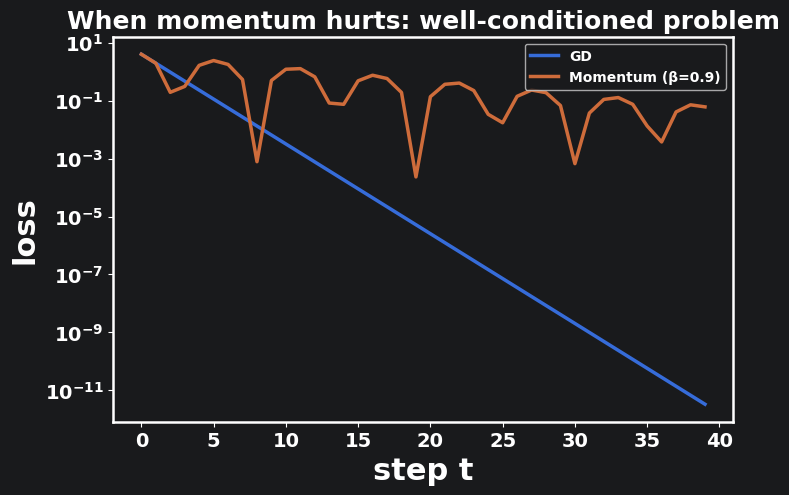

In [9]:
A = np.array([
    [1.0, 0.0],
    [0.0, 1.0]
])

f = quad2d(A)
x0 = torch.tensor([2.0, 2.0])

lr_gd = 0.3
lr_m  = 0.3
beta  = 0.9
steps = 40

xs_gd, losses_gd, _ = run_gd(x0, f, lr=lr_gd, steps=steps)
xs_m, vs_m, losses_m, _ = run_momentum(x0, f, lr=lr_m, beta=beta, steps=steps)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(losses_gd, linewidth=2.5, label="GD")
ax.plot(losses_m, linewidth=2.5, label=f"Momentum (β={beta})")
ax.set_yscale("log")
ax.set_title("When momentum hurts: well-conditioned problem", fontsize=18, fontweight="bold")
ax.set_xlabel("step t", fontsize=22, fontweight="bold")
ax.set_ylabel("loss", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"})
style_ax(ax)
plt.show()

##  8. Position vs Velocity: Understanding Momentum Dynamics

So far, we have viewed momentum through **trajectories and loss curves**.

Here, we go one level deeper and explicitly track both:
- the **position variables** $x_t$, and
- the **velocity variables** $v_t$

over time.

---

### What is being plotted

We run momentum on an **ill-conditioned quadratic**:

$$A = 
\begin{pmatrix} 
10 & 0 
\\ 0 & 1 
\end{pmatrix},$$

and record:
- **Left panel**: evolution of the position components
    - $x_1$: steep direction
    - $x_2$: flat direction
- **Right panel**: evolution of the velocity components
    - $v_1$: velocity in steep direction
    - $v_2$: velocity in flat direction

---

### What we observe

1. **Position variables** ($x_t$)
- $x_1$ (steep direction):
    - shows **rapid oscillations**
    - repeatedly overshoots the minimum
    - gradually damps over time
- $x_2$ (flat direction):
    - oscillates more slowly
    - moves more smoothly toward zero

👉 This reflects the **difference in curvature**:
- steep directions → fast, unstable motion
- flat directions → slow, smoother evolution

---

2. **Velocity variables** ($v_t$)
- $v_1$ (steep direction):
    - large magnitude
    - strong oscillations
    - frequently changes sign
- $v_2$ (flat direction):
    - smaller magnitude
    - smoother behaviour
    - decays more gradually

👉 The velocity reveals the **hidden dynamics**:
- it accumulates gradients,
- and drives the oscillatory behaviour seen in x_t.

---

### Key insight

> **Momentum introduces an additional state variable — velocity — which governs how updates evolve over time.**

Unlike gradient descent (which depends only on $x_t$), momentum operates as a system in:

$$(x_t, v_t)$$

This makes it fundamentally a **second-order dynamical system**.

---

### Physical interpretation

This behaviour closely resembles a **damped mechanical system**:
- $x_t$: position of a particle
- $v_t$: its velocity
- gradient: acts like a restoring force
- $\beta$: controls damping

From the plots:
- oscillations in $x_t$ correspond to underdamped motion
- decay of $v_t$ shows energy dissipation over time

---

### Takeaway

> **To understand momentum, you must look at both position and velocity.**

- The position tells you *where you are*
- The velocity tells you *how you are moving*

Together, they explain:
- oscillations,
- acceleration,
- and convergence behaviour.

This perspective makes it clear that momentum is not just a modification of gradient descent —

it is a fundamentally different **dynamical system with memory and inertia**.

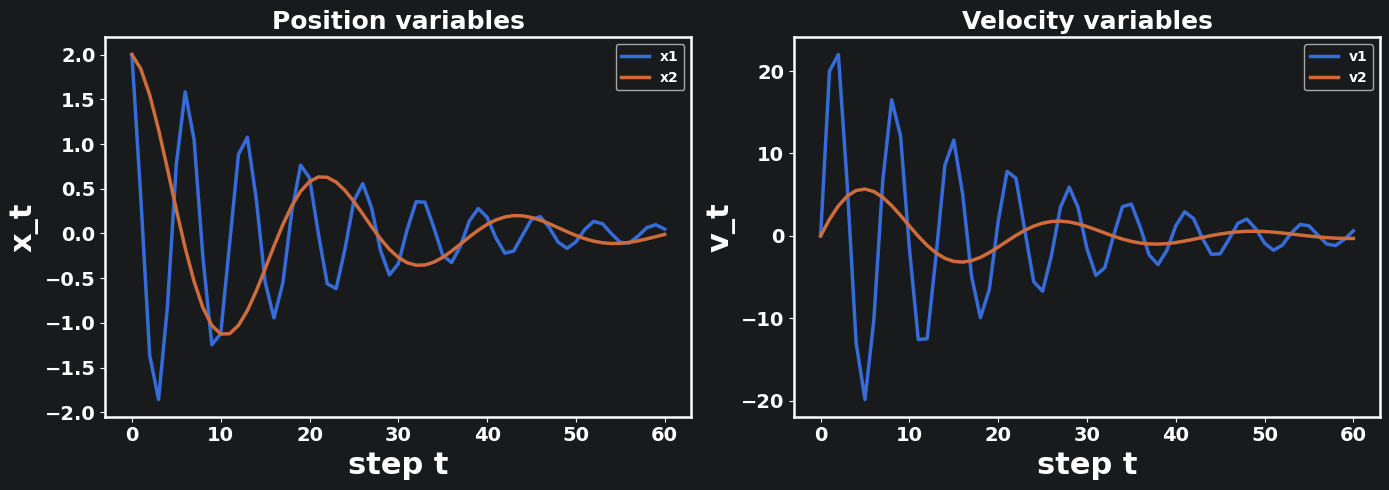

In [10]:
A = np.array([
    [10.0, 0.0],
    [0.0,  1.0]
])

f = quad2d(A)
x0 = torch.tensor([2.0, 2.0])

lr = 0.08
beta = 0.9
steps = 60

xs, vs, losses, _ = run_momentum(x0, f, lr=lr, beta=beta, steps=steps)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(xs[:,0].numpy(), linewidth=2.5, label="x1")
axes[0].plot(xs[:,1].numpy(), linewidth=2.5, label="x2")
axes[0].set_title("Position variables", fontsize=18, fontweight="bold")
axes[0].set_xlabel("step t", fontsize=22, fontweight="bold")
axes[0].set_ylabel("x_t", fontsize=22, fontweight="bold")
axes[0].legend(prop={"size":10, "weight":"bold"})
style_ax(axes[0])

axes[1].plot(vs[:,0].numpy(), linewidth=2.5, label="v1")
axes[1].plot(vs[:,1].numpy(), linewidth=2.5, label="v2")
axes[1].set_title("Velocity variables", fontsize=18, fontweight="bold")
axes[1].set_xlabel("step t", fontsize=22,  fontweight="bold")
axes[1].set_ylabel("v_t", fontsize=22, fontweight="bold")
axes[1].legend(prop={"size":10, "weight":"bold"})
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 9. Stronger Ill-Conditioning: Momentum Becomes More Useful

We now push the previous analysis further by considering a **more severely ill-conditioned problem**.

---

### Experimental setup

We define the quadratic objective:

$$
A =
\begin{pmatrix}
100 & 0 \\
0 & 1
\end{pmatrix},
$$

which introduces a much stronger imbalance in curvature:
- extremely steep direction ($x_1$),
- relatively flat direction ($x_2$).

This creates a **very narrow valley**, making optimisation significantly more challenging.

We compare:
- **Gradient descent** with learning rate $ \eta = 0.015 $
- **Momentum** with learning rate $ \eta = 0.008 $ and $ \beta = 0.9 $

Both methods start from the same initial point $x_0 = (2,2)$.

---

### What is being plotted

- The loss $L(x_t)$ as a function of iteration $t$
- A **logarithmic scale** on the y-axis to highlight convergence rates

---

### What we observe

**Gradient descent (GD)**
- Smooth and stable decrease in loss
- However, convergence is **very slow**
- Progress is limited by the need to remain stable in the steep direction

**Momentum**
- Exhibits strong **oscillations** due to inertia
- But the overall trend decreases **much faster**
- Eventually reaches significantly **lower loss values**

---

### Why momentum helps more here

In highly ill-conditioned problems:

- The condition number is large:
  $$
  \kappa = \frac{\lambda_{\max}}{\lambda_{\min}} = 100
  $$
- Gradient descent must take very small steps to remain stable:
  $$
  \eta \lesssim \frac{2}{\lambda_{\max}}
  $$
- This severely slows progress in flat directions

Momentum changes the dynamics by:

- accumulating gradients over time
- building up **velocity in consistent directions**
- effectively allowing faster motion along flat directions

Although it overshoots in the steep direction, the **net effect is acceleration**.

---

### Key insight

> The benefit of momentum increases with ill-conditioning.

- Mild ill-conditioning → modest benefit  
- Strong ill-conditioning → substantial improvement  

Momentum works by **partially overcoming curvature imbalance**, which becomes more severe as $\kappa$ increases.

---

### Takeaway

Momentum is most valuable when optimisation is hardest.

As the geometry becomes more anisotropic:
- gradient descent becomes increasingly inefficient
- momentum becomes increasingly beneficial

This reinforces a central principle:

> **The usefulness of optimisation methods depends on the geometry of the problem.**

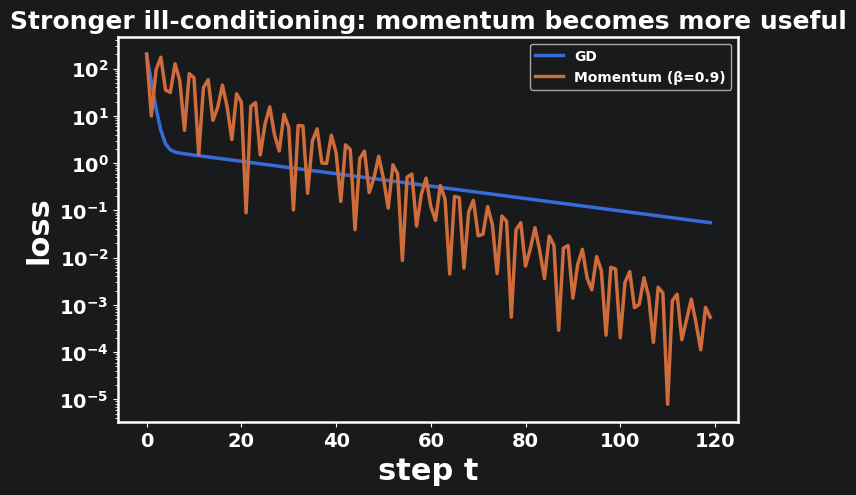

In [11]:
A = np.array([
    [100.0, 0.0],
    [0.0,   1.0]
])

f = quad2d(A)
x0 = torch.tensor([2.0, 2.0])

lr_gd = 0.015
lr_m  = 0.008
beta  = 0.9
steps = 120

xs_gd, losses_gd, _ = run_gd(x0, f, lr=lr_gd, steps=steps)
xs_m, vs_m, losses_m, _ = run_momentum(x0, f, lr=lr_m, beta=beta, steps=steps)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(losses_gd, linewidth=2.5, label="GD")
ax.plot(losses_m, linewidth=2.5, label=f"Momentum (β={beta})")
ax.set_yscale("log")
ax.set_title("Stronger ill-conditioning: momentum becomes more useful", fontsize=18, fontweight="bold")
ax.set_xlabel("step t", fontsize=22, fontweight="bold")
ax.set_ylabel("loss", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"})
style_ax(ax)
plt.show()

## 🧭 Closing remark

In this tutorial, we moved beyond gradient descent as a simple update rule and introduced a new idea:

> **Optimisation with memory.**

By adding momentum, we transformed the dynamics from:
- reacting only to the present
to
- **accumulating information over time**

---

Through a series of controlled experiments, we saw that:
- momentum can **accelerate optimisation** by building velocity in consistent directions
- it can **reduce inefficient zig-zagging** in ill-conditioned problems
- but it can also introduce **oscillations, overshooting, and instability**

Most importantly, we learned that:

> **Momentum is not universally helpful — its effect depends on the geometry of the problem.**

---

A key pattern emerged:
- well-conditioned problems → gradient descent is already optimal
- mildly ill-conditioned → momentum provides moderate gains
- strongly ill-conditioned → momentum becomes **essential**

This reflects a deeper idea:

> **Optimisation methods are not just algorithms — they are dynamical systems shaped by geometry.**

---

Another important insight is that momentum introduces a new dimension:
- we are no longer evolving just $x_t$
- but the pair $(x_t, v_t)$

This turns optimisation into a **second-order system**, where behaviour is governed by:
- inertia
- damping
- and stability trade-offs

---

If there is one takeaway from this tutorial, it is this:

> **Remembering the past can help — but only when used in the right way.**

Momentum is powerful because it changes how the system moves, not just *how fast*.

---

In the next tutorial, we will move beyond well-behaved quadratic objectives and ask what happens when optimisation is no longer guided by a single smooth valley.

In particular, we will study settings where:
- the objective has **multiple local minima**
- gradients can become **misleading or unstable**
- and local optimisation methods become increasingly sensitive to **initialisation, noise, and non-convex structure**

This will mark an important transition:

> **Even a well-designed optimisation algorithm is limited by the structure of the problem it is trying to solve.**

Understanding these limitations will prepare us for the next stage of the repository, where optimisation is no longer treated as a purely local process, but is guided by modelling and uncertainty.

What changes is not the importance of optimisation — but the need to go beyond it.